# Optical Simulation
This script do Jones calculus simulation for oke experiments

## import

In [22]:
import numpy as np
from scipy.signal import butter, filtfilt, hilbert
import matplotlib
import matplotlib.pyplot as plt
from dataclasses import dataclass
from tqdm import tqdm

## class and functions

In [23]:
@dataclass
class beam:
    ex: complex
    ey: complex

    @classmethod
    def make_beam_from_amplitude_phase(cls, ex_amp: float, ex_phase: float, ey_amp: float, ey_phase: float):
        ex = ex_amp * np.exp(1j * ex_phase)
        ey = ey_amp * np.exp(1j * ey_phase)
        return cls(ex, ey)
    
    @classmethod
    def make_linearly_polarized_source(cls, amp, angle):
        ex_amp = amp * np.cos(angle)
        ey_amp = amp * np.sin(angle)
        ex_phase = 0
        ey_phase = 0
        return cls.make_beam_from_amplitude_phase(ex_amp, ex_phase, ey_amp, ey_phase)

    def __add__(self, other):
        if not isinstance(other, beam):
            return NotImplemented
        ex = self.ex + other.ex
        ey = self.ey + other.ey
        return beam(ex, ey)

    def __sub__(self, other):
        if not isinstance(other, beam):
            return NotImplemented
        ex = self.ex - other.ex
        ey = self.ey - other.ey
        return beam(ex, ey)

    def times_matrix(self, mat: np.ndarray):
        if mat.shape != (2, 2):
            raise ValueError("Matrix must be 2x2")
        vec = np.array([self.ex, self.ey])
        result = mat @ vec
        ex_new, ey_new = result[0], result[1]
        return beam(ex_new, ey_new)
    
    # optical element from Jones calculus
    def apply_polarizer(self, angle: float):
        """
        Apply a polarizer at the given angle (in radians) to the beam.
        """
        c = np.cos(angle)
        s = np.sin(angle)
        mat = np.array([[c**2, c*s],
                        [c*s, s**2]])
        return self.times_matrix(mat)
    
    def apply_waveplate(self, angle: float, phase_shift: float):
        """
        Apply a waveplate at the given angle (in radians) with the specified phase shift to the beam.
        """
        c = np.cos(angle)
        s = np.sin(angle)
        mat = np.array([[c**2 + s**2 * np.exp(1j * phase_shift), c*s * (1 - np.exp(1j * phase_shift))],
                        [c*s * (1 - np.exp(1j * phase_shift)), s**2 + c**2 * np.exp(1j * phase_shift)]])
        return self.times_matrix(mat)
    
    # shortcuts for hwp and qwp
    def apply_hwp(self, angle: float):
        """
        Apply a half-wave plate at the given angle (in radians) to the beam.
        """
        return self.apply_waveplate(angle, np.pi)

    def apply_qwp(self, angle: float):
        """
        Apply a quarter-wave plate at the given angle (in radians) to the beam.
        """
        return self.apply_waveplate(angle, np.pi / 2)
    
    def apply_nd_filter(self, OD: float):
        """
        Apply a neutral density (ND) filter with the specified optical density (OD) to the beam.
        The optical density should be non-negative.
        """
        if OD < 0:
            raise ValueError("Optical density must be non-negative")

        attenuation = 10**(-OD / 2)
        return beam(self.ex * attenuation, self.ey * attenuation)

    def apply_wollaston(self, angle: float):
        """
        Apply a Wollaston prism at the given angle (in radians) to the beam.
        """
        angle1 = angle
        angle2 = angle + np.pi / 2
        beam1 = self.apply_polarizer(angle1)
        beam2 = self.apply_polarizer(angle2)
        return beam1, beam2

    def apply_pem(self, frequency:float, modulation:float, t:float):
        """
        Apply a photoelastic modulator (PEM) to the beam. The optical axis of PEM is set to be 0 degree.

        frequency: modulation frequency of the PEM (in Hz)
        modulation: modulation depth of the PEM (in radians)
        t: time at which to evaluate the modulation
        """
        phase = modulation * np.sin(2 * np.pi * frequency * t)
        return self.apply_waveplate(0, phase)

    # other physical processes:
    def apply_magnetic_sample(self, p_re:float, p_im:float, s_re:float, s_im:float, ps_re:float, ps_im:float):
        """
        Apply the effect of reflection on a mangnetic sample based on Jones calculus.
        A reflection on magnetic sample is represented by a 2*2 matrix
        [[rp, rps],
         [rsp, rs]]
        The diagonal term rp and rs obey Fresnel equations and independent of magnetic field.
        The off-diagonal term rps and rsp obeys rps = - rsp = rps_real * e^(i*delta_phase)
        
        Argument:
        rp: reflection coefficient for p-polarized light
        rps: reflection coefficient for conversion from s- to p-polarized light
        rs: reflection coefficient for s-polarized light
        """
        rp = p_re + 1j * p_im
        rs = s_re + 1j * s_im
        rps = ps_re + 1j * ps_im
        jones_matrix = np.array([[rp, rps],
                                 [-rps, rs]])
        return self.times_matrix(jones_matrix)

    def intensity(self):
        """
        Calculate the intensity of the beam.
        """
        return np.abs(self.ex)**2 + np.abs(self.ey)**2

    # other utilities
    def seperate_xy_beam(self):
        """
        Separate the beam into its x and y components as individual beams.
        """
        beam_x = beam(self.ex, 0)
        beam_y = beam(0, self.ey)
        return beam_x, beam_y

    def string_details(self):
        string = f"total beam intensity: {self.intensity()}\nx component intensity: {np.abs(self.ex)**2}\ny component intensity: {np.abs(self.ey)**2}\nxy_phase_difference: {np.angle(self.ex) - np.angle(self.ey)}"
        return string
    
    # visualization
    def plot_polarization_ellipse(self):
        """
        Plot the polarization ellipse of the beam.
        """
        t = np.linspace(0, 2 * np.pi, 1000)
        x = np.real(self.ex * np.exp(1j * t))
        y = np.real(self.ey * np.exp(1j * t))
        fig, ax = plt.subplots()
        ax.plot(x, y)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title("Polarization Ellipse")
        ax.axis("equal")
        return fig, ax

def kerr_angle(rp_re, rp_im, rps_re, rps_im, rs_re, rs_im,
                                    incident_deg, exact=False, units='deg'):
    """
    Compute Kerr rotation/ellipticity for arbitrary incident linear polarization
    angle psi (measured from the p-axis), to simulate polarizer misalignment.

    R = [[rp, rps], [-rps, rs]]
    Incident field (linear polarization at angle psi from p-axis):
        E_in = [cos(psi), sin(psi)]

    incident_deg: incident polarization angle in degrees.
             incident_deg = 0   -> nominal p-incidence
             incident_deg = 90  -> nominal s-incidence
             incident_deg = 0 + delta -> p-incidence with a small alignment error delta

    Returns: (theta_K, eta_K) — rotation and ellipticity of the reflected beam
             relative to the *incident* polarization axis (i.e. what a balanced
             polarimeter/analyzer referenced to psi would measure).
    """
    rp  = complex(rp_re, rp_im)
    rps = complex(rps_re, rps_im)
    rs  = complex(rs_re, rs_im)
    R = np.array([[rp, rps],
                  [-rps, rs]], dtype=complex)

    psi = np.radians(incident_deg)
    E_in = np.array([np.cos(psi), np.sin(psi)], dtype=complex)

    E_out = R @ E_in

    # Rotate reflected field into a frame aligned with the incident axis:
    # parallel component (along incident polarization) and perpendicular
    # component (the induced cross-polarization / Kerr signal)
    c, s = np.cos(psi), np.sin(psi)
    E_par  =  c * E_out[0] + s * E_out[1]
    E_perp = -s * E_out[0] + c * E_out[1]

    chi = E_perp / E_par   # complex polarization-plane leakage ratio

    Phi_K = np.arctan(chi) if exact else chi

    theta_K, eta_K = Phi_K.real, Phi_K.imag

    if units == 'deg':
        theta_K, eta_K = np.degrees(theta_K), np.degrees(eta_K)
    elif units == 'mdeg':
        theta_K, eta_K = np.degrees(theta_K) * 1e3, np.degrees(eta_K) * 1e3
    elif units != 'rad':
        raise ValueError("units must be 'rad', 'deg', or 'mdeg'")

    return theta_K, eta_K

def phase_from_edges(t, Iref, threshold=None):
    """
    Recover unwrapped reference phase from a step/square-wave reference
    via rising-edge detection with sub-sample interpolation.

    Parameters
    ----------
    t : 1D array, time (s), evenly spaced
    Iref : 1D array, step/square reference signal
    threshold : crossing level; defaults to the midpoint of Iref's range

    Returns
    -------
    phase_ref : 1D array, unwrapped fundamental phase (rad) at each t,
                referenced to 0 at the first detected rising edge and
                increasing by 2*pi per period thereafter
    """
    if threshold is None:
        threshold = (Iref.max() + Iref.min()) / 2

    above = Iref > threshold
    edges = np.where(np.diff(above.astype(int)) == 1)[0]  # rising-edge indices

    if len(edges) < 2:
        raise ValueError("Fewer than 2 rising edges found — check threshold "
                          "or signal quality.")

    # sub-sample edge timing via linear interpolation
    edge_times = []
    for i in edges:
        t0, t1 = t[i], t[i + 1]
        y0, y1 = Iref[i], Iref[i + 1]
        frac = (threshold - y0) / (y1 - y0)
        edge_times.append(t0 + frac * (t1 - t0))
    edge_times = np.array(edge_times)

    # phase increases by 2*pi between consecutive rising edges;
    # interpolate/extrapolate to cover the full t array
    phase_at_edges = 2 * np.pi * np.arange(len(edge_times))
    phase_ref = np.interp(t, edge_times, phase_at_edges)

    return phase_ref


def lockin_detect(t, Isig, Iref, n=1, lp_cutoff=None, filter_order=4, threshold=None):
    """
    Digital lock-in (synchronous) detection at the n-th harmonic of a
    step/square-wave reference, using edge-detected phase recovery.

    Parameters
    ----------
    t : 1D array, time (s), evenly spaced
    Isig : 1D array, signal to be demodulated
    Iref : 1D array, step/square reference signal (same length as t)
    n : harmonic number to demodulate (1 = fundamental, 2 = 2nd harmonic, ...)
    lp_cutoff : low-pass filter cutoff (Hz). Defaults to f_ref/10, where
                f_ref is the fundamental frequency estimated from Iref's
                edge spacing.
    order : Butterworth filter order
    threshold : edge-detection threshold for Iref; defaults to its midpoint

    Returns
    -------
    R : magnitude (same units as Isig)
    theta : phase (radians)
    X, Y : in-phase and quadrature components
    phase_ref : the recovered fundamental phase (rad), for diagnostics
    """
    dt = t[1] - t[0]
    fs = 1.0 / dt

    # --- recover fundamental phase from reference edges ---
    phase_ref = phase_from_edges(t, Iref, threshold=threshold)

    # estimate fundamental frequency from the phase ramp, for default cutoff
    f_ref_est = (phase_ref[-1] - phase_ref[0]) / (2 * np.pi * (t[-1] - t[0]))

    if lp_cutoff is None:
        lp_cutoff = f_ref_est / 10.0

    # --- build n-th harmonic reference quadratures ---
    ref_cos = np.cos(n * phase_ref)
    ref_sin = np.sin(n * phase_ref)

    # --- mix (demodulate) ---
    X_raw = Isig * ref_cos
    Y_raw = Isig * ref_sin

    # --- low-pass filter to reject 2*n*f_ref and neighboring harmonics ---
    b, a = butter(filter_order, lp_cutoff / (fs / 2), btype='low')
    X = filtfilt(b, a, X_raw)
    Y = filtfilt(b, a, Y_raw)

    # factor of 2 restores amplitude (mixing splits power into DC + 2*n*f terms)
    R = 2 * np.sqrt(X**2 + Y**2)
    theta = np.arctan2(Y, X)

    return R, theta, 2 * X, 2 * Y, phase_ref



## optical setup for calibration

In [24]:
# # parameters
# wavelength = 658e-9 # in meters
# t = np.arange(0, 0.5e-4, 1E-7)  # time array from 0 to 1 second 1 microsecond resolution.

# amp_noise = 0.010  # relative noise level for the light source
# hwp_pol_err = -0  # incident hwp error in angle
# pem_freq = 50 * 1e3  # frequency of the PEM in Hz
# pem_misphase_noise = 0.01 # misphase noise for the PEM
# pem_modulation = 180  # modulation  for the PEM in degree
# pem_modulation_err = 0 # absolution error for the PEM modulation in degree

# # for testing, use 2nd polarizer
# analyzer_pol = 135  # polarization angle of the analyzer polarizer in degree
# analyzer_pol_err = 0  # absolute error for the analyzer polarizer angle

## simulation calibration

In [25]:
# intensity = np.zeros(len(t))
# for i in tqdm(range(len(t))):
#     # light sources
#     l = beam.make_linearly_polarized_source(1.0+amp_noise*np.random.randn(), 0)   # horizontally polarized light with amplitude 1.0
#     # apply hwp to 45 deg
#     l = l.apply_hwp((22.5 + hwp_pol_err) * np.pi / 180)
#     # go through horizonal placed PEM
#     pem_mistime = pem_misphase_noise * np.random.randn() / pem_freq
#     l = l.apply_pem(pem_freq, (pem_modulation + pem_modulation_err) * np.pi / 180, t[i]+pem_mistime)
#     # apply second crossed polarizer
#     l = l.apply_polarizer((analyzer_pol + analyzer_pol_err) * np.pi / 180)  # crossed polarizer at 90 degrees
#     # analyze the resulting beam
#     intensity[i] = l.intensity()


# setup for MOKE

In [26]:
# parameters

wavelength = 658e-9 # in meters
# config: laser - hwp set laser to 90deg - sample - PEM at qwp mode, 0deg - 45 deg analyzer - detector
# laser
amp_noise = 0.0000  # relative noise level for the light source
# hwp
hwp_angle = 0
hwp_angle_err = 0  # incident hwp error in angle
# sample
sample_rp_re = 0.9  # real part of the reflection coefficient for p-polarized light
sample_rp_im = 0.1  # imaginary part of the reflection coefficient for p-polarized light
sample_rs_re = 0.8  # real part of the reflection coefficient for s-polarized light
sample_rs_im = 0.1  # imaginary part of the reflection coefficient for s-polarized light
sample_rps_re = 0.10*1e-3  # real part of the off-diagonal reflection coefficient
sample_rps_im = 0.00*1e-3  # imaginary part of the off-diagonal reflection coefficient
# pem
pem_freq = 50 * 1e3  # frequency of the PEM in Hz
pem_misphase_noise = 0.000 # misphase noise for the PEM, in ratio of the work cycle
pem_modulation = 90  # modulation  for the PEM in degree
pem_modulation_err = 0 # absolution error for the PEM modulation in degree
# analyzer
analyzer_angle = 135  # angle of the analyzer in degree
analyzer_angle_err = 0  # absolute error for the analyzer angle

kerr_rot, kerr_ell = kerr_angle(
    rp_re=sample_rp_re,
    rp_im=sample_rp_im,
    rps_re=sample_rps_re,
    rps_im=sample_rps_im,
    rs_re=sample_rs_re,
    rs_im=sample_rs_im,
    incident_deg=2*(hwp_angle+hwp_angle_err),  # assuming nominal p-incidence
    exact=True,
    units='deg'
)
print(f"theory Kerr rotation: {kerr_rot*1000:.2f} mdegree", )
print(f"theory Kerr ellipticity: {kerr_ell*1000:.2f} mdegree")

# time
t_end = 1    # s
sampling_rate = 1e6 # sampling rate in Hz
t = np.linspace(0, t_end, int(sampling_rate * t_end))  # time array from 0 to t_end with the given sampling rate.
dt = t[1] - t[0]
ns = pem_freq * dt
print(f"t_reso = {dt:.2g}, measure_per_period = {1/ns:.2g}")

# trigger to view polarization analysis
trig_view_pol = False


theory Kerr rotation: -6.29 mdegree
theory Kerr ellipticity: 0.70 mdegree
t_reso = 1e-06, measure_per_period = 20


In [27]:
intensity = np.zeros(len(t))
l0s = []
l1s = []
l2s = []
l3s = []
l4s = []
for i in tqdm(range(len(t))):
    # laser
    l0 = beam.make_linearly_polarized_source(1.0+amp_noise*np.random.randn(), 0)   # horizontally polarized light with amplitude 1.0
    # hwp
    l1 = l0.apply_hwp((hwp_angle+hwp_angle_err) * np.pi / 180)
    # sample
    l2 = l1.apply_magnetic_sample(sample_rp_re, sample_rp_im, sample_rs_re, sample_rs_im, sample_rps_re, sample_rps_im)
    # PEM
    pem_mistime = pem_misphase_noise * np.random.randn() / pem_freq
    l3 = l2.apply_pem(pem_freq, (pem_modulation + pem_modulation_err) * np.pi / 180, t[i]+pem_mistime)
    # analyzer
    l4 = l3.apply_polarizer((analyzer_angle + analyzer_angle_err) * np.pi / 180)
    intensity[i] = l4.intensity()
    # only save ls if needed for polarization analysis
    if trig_view_pol:
        l0s.append(l0)
        l1s.append(l1)
        l2s.append(l2)
        l3s.append(l3)
        l4s.append(l4)
    

100%|██████████| 1000000/1000000 [00:48<00:00, 20739.27it/s]


## visualization

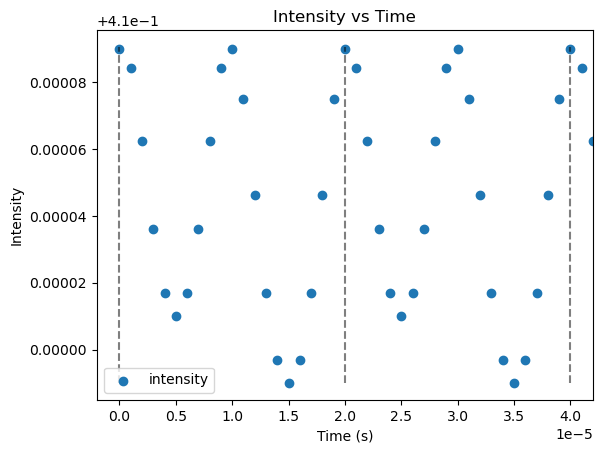

In [28]:
%matplotlib inline
t_cycle = 1 / pem_freq
t_cycle_ends = np.arange(0,  t[-1], t_cycle)
fig, ax = plt.subplots()
ax.scatter(t, intensity, label = 'intensity')
ax.vlines(t_cycle_ends, ymin=intensity.min(), ymax=intensity.max(), color='k', alpha=0.5, linestyle='--')
ax.set_xlim(-t_cycle*0.1, 2.1*t_cycle)
ax.legend()
ax.set_xlabel('Time (s)')
ax.set_ylabel('Intensity')
ax.set_title('Intensity vs Time')
plt.show()

## time-resolved polarization state plot

In [29]:
if trig_view_pol:
    # ----- params -----
    n_frame = 32
    # ----- end params -----

    dir_out = r'F:\OneDrive - purdue.edu\Data\Simulation\260717 PEM MOKE\1'
    matplotlib.use('Agg')
    # get representative frames
    t_cycle = 1 / pem_freq
    t_frames = np.linspace(0, t_cycle, n_frame, endpoint=False)
    for i in range(n_frame):
        id_frame = np.argmin(np.abs(t - t_frames[i]))
        # l0 = l0s[id_frame]
        l1 = l1s[id_frame]
        l2 = l2s[id_frame]
        l3 = l3s[id_frame]
        l4 = l4s[id_frame]
        ls = [l1, l2, l3, l4]
        subtitle = [
            # "laser",
            "hwp",
            "sample",
            "pem",
            "analyzer"
        ]
        figs = []
        axes = []
        annotations = []
        for j, l in enumerate(ls):
            fig, ax = l.plot_polarization_ellipse()
            figs.append(fig)
            axes.append(ax)
            ex_amp, ex_phase_deg = np.abs(l.ex), np.degrees(np.angle(l.ex))
            ey_amp, ey_phase_deg = np.abs(l.ey), np.degrees(np.angle(l.ey))
            annotations.append(
                f"Ex: {ex_amp:.2g} ∠ {ex_phase_deg:.2g}°\n"
                f"Ey: {ey_amp:.2g} ∠ {ey_phase_deg:.2g}°"
            )
        fig_super = plt.figure(figsize=(10,10))
        gs = fig_super.add_gridspec(2, 2)
        for j, (fig, ax) in enumerate(zip(figs, axes)):
            ax_super = fig_super.add_subplot(gs[j // 2, j % 2])
            for line in ax.get_lines():
                ax_super.plot(line.get_xdata(), line.get_ydata())
            ax_super.set_title(subtitle[j])
            ax_super.set_aspect('equal') 
            ax_super.set_xlim(-1.1, 1.1)
            ax_super.set_ylim(-1.1, 1.1)
            ax_super.text(0.02, 0.98, annotations[j], transform=ax_super.transAxes,
                        va='top', ha='left', fontsize=9,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        fig_super.savefig(f'{dir_out}/frame_{i}_summary.png')
        plt.close("all")

## lockin detection

Lock in detection: time range is 0.0005 to 0.0045 s
R = 0.0071±0.044, theta = 1.3±1.3


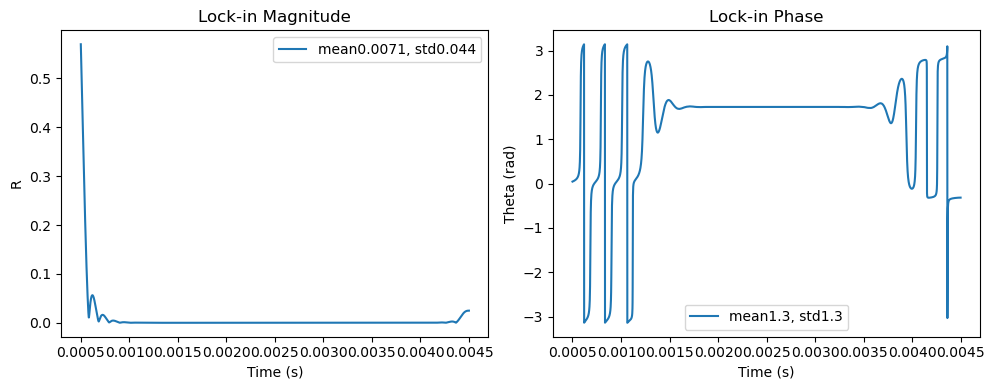

In [32]:
from scipy import signal
# ----- params -----
lock_in_order = 1
lock_in_mimic_chopper_freq = 200    # unit in Hz
lock_in_mimic_chopper_delay_ratio = 0.1     # delay between chopper signal and measurement start
lock_in_integration_time_ratio = 0.8  # working ratio of lock-in integration compare with chopper frequency
# ----- end -----
# generate reference signal
ref_signal = signal.square(2 * np.pi * pem_freq * t)

# generate chopper and measurement cycle
measurement_time = 1 / lock_in_mimic_chopper_freq * lock_in_integration_time_ratio
measurement_start = 1 / lock_in_mimic_chopper_freq * lock_in_mimic_chopper_delay_ratio
measure_mask = (t > measurement_start) & (t < measurement_start + measurement_time)

R, theta, _, _, _ = lockin_detect(t[measure_mask], intensity[measure_mask], ref_signal[measure_mask], n = lock_in_order, filter_order=4)
t_measure = t[measure_mask]
R_mean, theta_mean = R.mean(), theta.mean()
R_std, theta_std = R.std(), theta.std()
print(f"Lock in detection: time range is {t_measure[0]:.3g} to {t_measure[-1]:.3g} s\nR = {R_mean:.2g}±{R_std:.2g}, theta = {theta_mean:.2g}±{theta_std:.2g}")

# visualization
%matplotlib inline
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(t_measure, R, label=f"mean{R_mean:.2g}, std{R_std:.2g}")
ax[0].legend()
ax[0].set_title("Lock-in Magnitude")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("R")
ax[1].plot(t_measure, theta, label=f"mean{theta_mean:.2g}, std{theta_std:.2g}")
ax[1].set_title("Lock-in Phase")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Theta (rad)")
ax[1].legend()
plt.tight_layout()
plt.show()